# Saans - Chest X-ray TB Model (local edition)

The four-dataset training notebook, set up to run on your own machine in VS Code
rather than in Colab. Same model and same data as v2.

**Requires the `saans` conda environment** - TensorFlow 2.10 on Python 3.10, which
is the last combination with GPU support on native Windows. If the environment
check below reports no GPU, stop and fix that first: on CPU this will not finish.

> **Honest scope note:** Trained on adult TB CXR datasets as proof-of-concept; paediatric fine-tuning is the Phase-1 pilot roadmap item.

**What changed from v1**

|                  | v1                        | v2                                             |
| ---------------- | ------------------------- | ---------------------------------------------- |
| Images           | 800                       | ~16,000                                        |
| Sources          | NLM Shenzhen + Montgomery | those two, plus TBX11K and the Qatar/Dhaka set |
| "Negative" class | healthy films only        | healthy films **and sick-but-not-TB films**    |
| Split            | train / validation        | train / validation / **untouched test**        |
| Duplicate check  | none                      | perceptual hash across all four sources        |
| Threshold        | left at 0.5               | chosen on validation for a recall target       |
| Headline metric  | accuracy                  | AUC + recall on the test set                   |

The two additions that matter most:

**Sick-but-not-TB films.** In v1 every negative was a healthy chest. A model
trained that way only has to learn "does this lung look abnormal", which is a
much easier - and much less useful - question than "is this abnormality TB".
TBX11K contributes ~5,000 films of people who are ill with something that is not
tuberculosis. That is the hard negative class, and it is what v1 was missing.

**A test set that nothing touches.** In v1 the same 160 images picked the early
stopping point and produced the final numbers, which makes those numbers
optimistic. Here, validation drives training and threshold choice, and the test
set is scored exactly once at the end.

**Before you run:** pick the `saans` kernel (top right of this notebook), and
have your Kaggle API token in place (Block 1 explains how). Budget roughly 40
minutes of downloading and 60-90 minutes of training on a laptop 3050.

The downloads and the decoded-image cache persist on your disk, so every run
after the first starts at Block 3.


In [2]:
# Environment check - run this first, and read the output.
import sys

import tensorflow as tf

print("Python     ", sys.version.split()[0], "(TensorFlow 2.10 needs 3.10)")
print("TensorFlow ", tf.__version__, "(needs to be 2.10.x on native Windows)")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU         OK ->", gpus[0].name)
    # 4 GB card: let TensorFlow take memory as it needs it rather than reserving
    # the whole device up front, which leaves room for the decoded image array.
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as exc:
            print("            (memory growth already set:", exc, ")")
else:
    print()
    print("GPU         NOT FOUND - TensorFlow is only seeing the CPU.")
    print()
    print("Most likely one of these:")
    print("  * TensorFlow is newer than 2.10  ->  pip install \"tensorflow<2.11\"")
    print("  * Python is 3.11 or newer        ->  the saans env must be Python 3.10")
    print("  * cudatoolkit / cudnn missing    ->  conda install -c conda-forge cudatoolkit=11.2 cudnn=8.1.0")
    print("  * the wrong kernel is selected   ->  top right of this notebook, pick 'saans'")
    print()
    print("Do not continue on CPU - training would take days.")

Python      3.10.21 (TensorFlow 2.10 needs 3.10)
TensorFlow  2.10.1 (needs to be 2.10.x on native Windows)
GPU         OK -> /physical_device:GPU:0


## BLOCK 1 - Download four datasets

**Two come from NIH NLM, no login needed:**

- Shenzhen (China set) - `ChinaSet_AllFiles.zip`, ~662 films
- Montgomery County - `MontgomeryCountyXRaySet.zip`, ~138 films

**Two come from Kaggle, which needs an API token:**

- TBX11K - `usmanshams/tbx-11`, ~11,200 films
- Qatar/Dhaka TB database - `tawsifurrahman/tuberculosis-tb-chest-xray-dataset`, ~4,200 films

### Getting your Kaggle token (one minute, once)

1. Go to <https://www.kaggle.com/settings> while logged in.
2. Scroll to **API** and create a **legacy API key** - that is the one that
   downloads a `kaggle.json` file. Kaggle's newer key types show you a value on
   screen instead and do not produce the file this notebook looks for.
3. The download is silent - no "save as" prompt. Look in your **Downloads**
   folder for `kaggle.json` (it is tiny, about 70 bytes).
4. Move `kaggle.json` into `C:\Users\<your name>\.kaggle\`. Create the
   `.kaggle` folder if it does not exist (the leading dot is part of the name).

The cell also checks your Downloads folder and the folder this notebook sits in,
so if you skip step 4 it will most likely still find the file and copy it into
place for you.

Labels come from two conventions, depending on the source: the NLM filename
suffix (`..._0.png` = Normal, `..._1.png` = TB), and folder names everywhere else.


In [3]:
# BLOCK 1 - DOWNLOAD DATA
# Downloads land in DATA_ROOT on your own disk and stay there between runs.

import json
import os
import shutil
import subprocess
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

DATA_ROOT = Path(os.environ.get("SAANS_DATA", r"D:\saans_data"))
RAW_DIR = DATA_ROOT / "raw"
EXTRACT_DIR = DATA_ROOT / "extracted"
RAW_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

NIH_PAGE = "https://lhncbc.nlm.nih.gov/LHC-publications/downloads/TuberculosisChestXrayImageDataSets.html"

# --- the two NLM sets, fetched straight over https -------------------------
NLM_SETS = {
    "shenzhen": {
        "zip": "ChinaSet_AllFiles.zip",
        "prefix": "CHNCXR",
        "urls": [
            "https://data.lhncbc.nlm.nih.gov/public/Tuberculosis-Chest-X-ray-Datasets/China-CXRSet/ChinaSet_AllFiles.zip",
            "https://openi.nlm.nih.gov/imgs/collections/ChinaSet_AllFiles.zip",
        ],
        "kaggle_fallback": "https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-shenzhen",
    },
    "montgomery": {
        "zip": "MontgomeryCountyXRaySet.zip",
        "prefix": "MCUCXR",
        "urls": [
            "https://data.lhncbc.nlm.nih.gov/public/Tuberculosis-Chest-X-ray-Datasets/Montgomery-County-CXR-Set/MontgomerySet.zip",
            "https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip",
        ],
        "kaggle_fallback": "https://www.kaggle.com/datasets/raddar/tuberculosis-chest-xrays-montgomery",
    },
}

# --- the two Kaggle sets ---------------------------------------------------
KAGGLE_SETS = {
    "tbx11k": "usmanshams/tbx-11",
    "qatar": "tawsifurrahman/tuberculosis-tb-chest-xray-dataset",
}


def extract_local_zips():
    """Unzip anything sitting in raw/, or dropped next to the notebook, into EXTRACT_DIR."""
    candidates = list(RAW_DIR.glob("*.zip")) + list(Path.cwd().glob("*.zip"))
    for zpath in sorted(set(candidates)):
        if not zipfile.is_zipfile(zpath):
            continue
        marker = EXTRACT_DIR / (".done_" + zpath.name)
        if marker.exists():
            continue
        print(f"  extracting {zpath.name} ...")
        with zipfile.ZipFile(zpath) as zf:
            zf.extractall(EXTRACT_DIR / zpath.stem)
        marker.write_text("ok")


def nlm_images(prefix):
    """
    NLM films on disk. The Montgomery zip also ships hand-drawn lung masks under
    ManualMask/ with the SAME filenames as the films - excluding any path with
    'mask' in it keeps those binary masks out of the training set.
    """
    return sorted(
        p
        for p in EXTRACT_DIR.rglob("*")
        if p.suffix.lower() in {".png", ".jpg", ".jpeg"}
        and p.name.upper().startswith(prefix)
        and p.stem.rsplit("_", 1)[-1] in {"0", "1"}
        and "mask" not in str(p).lower()
        and "__MACOSX" not in str(p)
    )


def http_download(url, dest):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (Saans training notebook)"})
    with urllib.request.urlopen(req, timeout=180) as resp, open(dest, "wb") as fh:
        total = int(resp.headers.get("Content-Length") or 0)
        done = 0
        while True:
            chunk = resp.read(1 << 20)
            if not chunk:
                break
            fh.write(chunk)
            done += len(chunk)
            tail = f" / {total / 1e6:.1f} MB" if total else ""
            print(f"\r    {done / 1e6:7.1f} MB{tail}", end="")
    print()
    if not zipfile.is_zipfile(dest):
        dest.unlink(missing_ok=True)
        raise RuntimeError("server returned something that is not a zip (an HTML error page?)")


print("=" * 70)
print("NLM sets")
print("=" * 70)
extract_local_zips()

for key, spec in NLM_SETS.items():
    if nlm_images(spec["prefix"]):
        print(f"  {key:11s} already present: {len(nlm_images(spec['prefix']))} films")
        continue
    print(f"\nDownloading {key} ({spec['zip']}) ...")
    for url in spec["urls"]:
        try:
            print(f"  trying {url}")
            http_download(url, RAW_DIR / spec["zip"])
            break
        except (urllib.error.URLError, urllib.error.HTTPError, RuntimeError, TimeoutError, OSError) as exc:
            print(f"  ! failed: {type(exc).__name__}: {exc}")
    extract_local_zips()
    n = len(nlm_images(spec["prefix"]))
    if n:
        print(f"  {key} ready: {n} films")
    else:
        print(f"  Download failed. Go to {spec['kaggle_fallback']}, download the zip manually,")
        print("  and upload it to Colab using the folder icon on the left, then re-run this cell.")

NLM sets
  shenzhen    already present: 989 films
  montgomery  already present: 211 films


In [4]:
# BLOCK 1 (cont.) - the two Kaggle sets.
# Repeated here so this cell runs on its own; it still needs EXTRACT_DIR and
# KAGGLE_SETS from the cell above, so run that one first.
import json
import os
import shutil
import subprocess
from pathlib import Path


def ensure_kaggle_auth():
    """The Kaggle CLI wants ~/.kaggle/kaggle.json. On Windows that folder is
    C:/Users/<your name>/.kaggle - put the file you downloaded from
    kaggle.com/settings there and this returns straight away."""
    target = Path.home() / ".kaggle" / "kaggle.json"
    if target.exists():
        print(f"  using {target}")
        return True

    # otherwise look for it next to the notebook or in Downloads, including the
    # "kaggle (1).json" name a second download produces
    search_dirs = [Path.cwd(), Path.cwd().parent, Path.home() / "Downloads"]
    for folder in search_dirs:
        for candidate in sorted(folder.glob("*kaggle*.json")):
            if candidate.is_file():
                target.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy(candidate, target)
                print(f"  copied {candidate} -> {target}")
                return True
    return False


def kaggle_download(name, slug):
    dest = EXTRACT_DIR / name
    if dest.exists() and any(dest.rglob("*.png")) or (dest.exists() and any(dest.rglob("*.jpg"))):
        print(f"  {name:8s} already present")
        return True

    dest.mkdir(parents=True, exist_ok=True)
    print(f"\nDownloading {name} ({slug}) - several GB, this takes a while ...")
    # Output is NOT captured, so the Kaggle CLI's progress bar reaches the cell.
    # Capturing it makes the cell look frozen for 20 minutes.
    proc = subprocess.run(["kaggle", "datasets", "download", "-d", slug, "-p", str(dest), "--unzip", "--force"])
    if proc.returncode != 0:
        print(f"  ! kaggle CLI failed for {slug} (exit {proc.returncode}) - see the output above")
        return False
    n = sum(1 for p in dest.rglob("*") if p.suffix.lower() in {".png", ".jpg", ".jpeg"})
    print(f"  {name} ready: {n} image files")
    return True


print("=" * 70)
print("Kaggle sets")
print("=" * 70)

subprocess.run(["pip", "install", "-q", "kaggle"], capture_output=True)

if not ensure_kaggle_auth():
    print()
    print("No Kaggle credentials found. Do this, then re-run this cell:")
    print("  1. open https://www.kaggle.com/settings")
    print("  2. under API, create a LEGACY API key - kaggle.json downloads")
    print(f"  3. move kaggle.json into {Path.home() / '.kaggle'}")
    print("     (create that folder if it does not exist)")
    raise SystemExit

for name, slug in KAGGLE_SETS.items():
    kaggle_download(name, slug)

Kaggle sets
  using C:\Users\HP\.kaggle\kaggle.json
  tbx11k   already present
  qatar    already present


In [5]:
# BLOCK 1 (cont.) - build one labelled index across all four sources.
import pandas as pd

# Folder names that identify a class. Matched against whole path SEGMENTS, never
# as substrings: the folder 'TBX11K' contains the letters 'tb' and a substring
# match would label every image in the dataset as tuberculosis.
TB_DIRS = {"tb", "tuberculosis", "tuberculose", "active_tb", "activetb", "tb_positive", "abnormal_tb"}
NEG_DIRS = {
    "normal", "normals", "health", "healthy", "non_tb", "nontb", "negative",
    "sick", "sick_non_tb", "no_finding", "nofinding", "other",
}

CLASS_NAMES = ["Normal", "TB"]


def label_from_folders(path):
    """Walk the folders from the deepest upward and take the first class we recognise."""
    for part in reversed(path.parts[:-1]):
        seg = part.strip().lower().replace("-", "_").replace(" ", "_")
        if seg in TB_DIRS:
            return 1
        if seg in NEG_DIRS:
            return 0
    return None


def label_for(path):
    name = path.name.upper()
    if name.startswith(("CHNCXR", "MCUCXR")):        # NLM filename convention
        suffix = path.stem.rsplit("_", 1)[-1]
        return int(suffix) if suffix in {"0", "1"} else None
    return label_from_folders(path)


def source_for(path):
    rel = path.relative_to(EXTRACT_DIR).parts[0].lower()
    name = path.name.upper()
    if name.startswith("CHNCXR"):
        return "shenzhen"
    if name.startswith("MCUCXR"):
        return "montgomery"
    if "tbx" in rel:
        return "tbx11k"
    return "qatar" if "tuberculosis" in rel or "qatar" in rel else rel


rows, unlabelled = [], []
for p in EXTRACT_DIR.rglob("*"):
    if p.suffix.lower() not in {".png", ".jpg", ".jpeg"}:
        continue
    if "mask" in str(p).lower() or "__MACOSX" in str(p):
        continue
    label = label_for(p)
    if label is None:
        unlabelled.append(p)
        continue
    rows.append({"path": str(p), "label": label, "source": source_for(p)})

df = pd.DataFrame(rows).drop_duplicates(subset="path")
# NLM films first, so that if the same image appears in two sources the original
# survives the de-duplication step in Block 2.
order = {"shenzhen": 0, "montgomery": 1, "qatar": 2, "tbx11k": 3}
df = df.sort_values(by="source", key=lambda s: s.map(order).fillna(9)).reset_index(drop=True)

print(f"labelled files:   {len(df)}")
print(f"unlabelled files: {len(unlabelled)}  (skipped - no class folder we recognise)")
print()
print(pd.crosstab(df["source"], df["label"].map({0: "Normal", 1: "TB"}), margins=True))

if unlabelled:
    print("\nExamples of what was skipped (folder -> filename):")
    for p in unlabelled[:8]:
        print("   ", p.parent.relative_to(EXTRACT_DIR), "->", p.name)
    print("If a whole dataset is missing above, its folders are named something this")
    print("notebook does not recognise - add those names to TB_DIRS / NEG_DIRS and re-run.")

if df.empty:
    raise RuntimeError("No labelled images found at all - check the download steps above.")

labelled files:   13800
unlabelled files: 3479  (skipped - no class folder we recognise)

label       Normal    TB    All
source                         
montgomery     122    89    211
qatar         3500   700   4200
shenzhen       486   503    989
tbx11k        7600   800   8400
All          11708  2092  13800

Examples of what was skipped (folder -> filename):
    tbx11k\TBX11K -> teaser.jpg
    tbx11k\TBX11K\imgs\extra\da+db\train -> n11.png
    tbx11k\TBX11K\imgs\extra\da+db\train -> n12.png
    tbx11k\TBX11K\imgs\extra\da+db\train -> n13.png
    tbx11k\TBX11K\imgs\extra\da+db\train -> n14.png
    tbx11k\TBX11K\imgs\extra\da+db\train -> n17.png
    tbx11k\TBX11K\imgs\extra\da+db\train -> n20.png
    tbx11k\TBX11K\imgs\extra\da+db\train -> n21.png
If a whole dataset is missing above, its folders are named something this
notebook does not recognise - add those names to TB_DIRS / NEG_DIRS and re-run.


## BLOCK 2 - Preprocess, de-duplicate, three-way split

Same preprocessing as v1 - RGB, 224x224, `densenet.preprocess_input`, flip /
rotate / zoom on the training split only - with two additions.

**De-duplication.** The Qatar/Dhaka database was assembled partly from the same
NLM sources this notebook downloads directly, so the same film can arrive twice
under different names. If one copy landed in training and the other in test, the
test score would be inflated and the model would look better than it is. Every
image gets a small perceptual hash (16x16, thresholded at its own mean); exact
hash collisions are dropped, keeping the NLM original where there is a choice.

**Three-way split, 70 / 15 / 15.** Training fits the weights. Validation picks
the stopping point and the decision threshold. Test is scored once, at the very
end, and influences nothing.


In [6]:
# BLOCK 2 - PREPROCESS
import os
from concurrent.futures import ThreadPoolExecutor

import cv2
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.densenet import preprocess_input
from tqdm.auto import tqdm

IMG_SIZE = 224          # 320 would resolve fine detail better, at ~2x the training time
BATCH_SIZE = 16        # 4 GB of VRAM. If you still get an OOM error, drop this to 8.
SEED = 42

CACHE_X = DATA_ROOT / f"decoded_{IMG_SIZE}.npy"
CACHE_DF = DATA_ROOT / f"decoded_{IMG_SIZE}_index.csv"

tf.keras.utils.set_random_seed(SEED)


def decode_and_hash(path):
    """One decode per file: gives back the 224 training image AND its perceptual hash."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:                                   # cv2 refused it - try PIL
        with Image.open(path) as im:
            img = np.asarray(im.convert("L"))
    tiny = cv2.resize(img, (16, 16), interpolation=cv2.INTER_AREA)
    digest = np.packbits(tiny > tiny.mean()).tobytes().hex()
    big = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return np.repeat(big[:, :, None], 3, axis=2), digest


if CACHE_X.exists() and CACHE_DF.exists():
    X = np.load(CACHE_X, mmap_mode="r")
    df = pd.read_csv(CACHE_DF)
    print(f"loaded {len(df)} decoded images from cache")
else:
    n = len(df)
    X_all = np.empty((n, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)   # preallocated: no np.stack copy
    hashes = [None] * n
    with ThreadPoolExecutor(max_workers=8) as pool:
        stream = pool.map(decode_and_hash, df["path"].tolist())
        for i, (arr, digest) in enumerate(tqdm(stream, total=n, desc="decoding")):
            X_all[i] = arr
            hashes[i] = digest

    df = df.assign(phash=hashes)
    keep = ~df.duplicated(subset="phash", keep="first")     # NLM originals sorted first, so they win
    print(f"\nduplicate films dropped: {int((~keep).sum())}")
    X = np.ascontiguousarray(X_all[keep.to_numpy()])
    df = df[keep].reset_index(drop=True)
    del X_all

    np.save(CACHE_X, X)
    df.to_csv(CACHE_DF, index=False)
    print(f"cached -> {CACHE_X}")

y = df["label"].to_numpy().astype("float32")
print(f"\nX: {X.shape} {X.dtype}   ({X.nbytes / 1e9:.2f} GB in RAM)")
print(f"TB fraction: {y.mean():.3f}")
print()
print(pd.crosstab(df["source"], df["label"].map({0: "Normal", 1: "TB"}), margins=True))

loaded 13265 decoded images from cache

X: (13265, 224, 224, 3) uint8   (2.00 GB in RAM)
TB fraction: 0.143

label       Normal    TB    All
source                         
montgomery      87    64    151
qatar         3500   692   4192
shenzhen       338   346    684
tbx11k        7438   800   8238
All          11363  1902  13265


e:\minianaconda\envs\saans\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# BLOCK 2 (cont.) - three-way split and the tf.data pipelines.
idx_all = np.arange(len(y))
idx_train, idx_hold = train_test_split(idx_all, test_size=0.30, random_state=SEED, stratify=y)
idx_val, idx_test = train_test_split(idx_hold, test_size=0.50, random_state=SEED, stratify=y[idx_hold])

X_train, y_train = np.asarray(X[idx_train]), y[idx_train]
X_val, y_val = np.asarray(X[idx_val]), y[idx_val]
X_test, y_test = np.asarray(X[idx_test]), y[idx_test]

df_val = df.iloc[idx_val].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

for name, arr in (("train", y_train), ("val", y_val), ("test", y_test)):
    print(f"{name:5s}: {len(arr):6d}   TB {int(arr.sum()):5d} / Normal {int((1 - arr).sum()):5d}   ({arr.mean():.1%} TB)")

augment = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.06, fill_mode="nearest", seed=SEED),   # ~ +/-21 degrees
        tf.keras.layers.RandomZoom(0.10, fill_mode="nearest", seed=SEED),
    ],
    name="augmentation",
)


def make_dataset(images, labels, training):
    # Build the pipeline on the CPU. from_tensor_slices() makes the entire array
    # one constant tensor, and eager mode places it on the GPU by default - 1.4 GB
    # of training images would eat most of a 4 GB card before the model loads.
    # On the CPU the images stay in system RAM and cross to the GPU one batch at a time.
    with tf.device("/cpu:0"):
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        if training:
            ds = ds.shuffle(min(len(images), 4096), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.batch(BATCH_SIZE)

        def prep(xb, yb):
            xb = tf.cast(xb, tf.float32)
            if training:
                xb = augment(xb, training=True)
            return preprocess_input(xb), yb

        ds = ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val, training=False)      # unshuffled: predictions stay aligned
test_ds = make_dataset(X_test, y_test, training=False)
print()
print("steps per epoch:", len(train_ds))

train:   9285   TB  1331 / Normal  7954   (14.3% TB)
val  :   1990   TB   286 / Normal  1704   (14.4% TB)
test :   1990   TB   285 / Normal  1705   (14.3% TB)

steps per epoch: 581


## BLOCK 3 - Train

Same two-phase transfer learning as v1, with the settings that worked, plus
mixed precision so the T4 uses its tensor cores (roughly half the training time).
The final layer is forced back to float32 - a float16 sigmoid loses precision
exactly where the probabilities matter.

Fewer epochs than v1, because each epoch now covers ~20x more images.

Note on metrics: with roughly 12% of films positive, **accuracy is close to
useless** - always predicting "Normal" would score about 88%. Watch AUC, PR-AUC
and recall instead.


In [9]:
# BLOCK 3 - TRAIN
# Trained on adult TB CXR datasets as proof-of-concept; paediatric fine-tuning
# is the Phase-1 pilot roadmap item.
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import callbacks, layers, models, optimizers

USE_MIXED_PRECISION = True      # set False if you hit anything strange on a non-T4 GPU
if USE_MIXED_PRECISION and tf.config.list_physical_devices("GPU"):
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("mixed precision:", tf.keras.mixed_precision.global_policy().name)

inputs = layers.Input((IMG_SIZE, IMG_SIZE, 3), name="cxr_input")
base = tf.keras.applications.DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
x = layers.GlobalAveragePooling2D(name="gap")(base.output)
x = layers.Dropout(0.3, name="drop")(x)
# dtype float32 on the head: keep the probability itself out of float16
outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="tb_output")(x)
model = models.Model(inputs, outputs, name="saans_xray_densenet121")

METRICS = [
    "accuracy",
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
]

class_weight = dict(enumerate(compute_class_weight("balanced", classes=np.array([0.0, 1.0]), y=y_train)))
print("class weights:", {int(k): round(float(v), 3) for k, v in class_weight.items()})

# ---- Phase 1: frozen backbone, train the head only ------------------------
base.trainable = False
model.compile(optimizer=optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=METRICS)
print(f"trainable params (phase 1): {int(sum(np.prod(w.shape) for w in model.trainable_weights)):,}")

hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    class_weight=class_weight,
    callbacks=[callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True)],
    verbose=1,
)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
mixed precision: mixed_float16
29084464/29084464 [==============================] - 13s 0us/step
class weights: {0: 0.584, 1: 3.488}
trainable params (phase 1): 1,025
Epoch 1/6
581/581 [==============================] - 63s 83ms/step - loss: 0.5926 - accuracy: 0.6891 - auc: 0.7540 - pr_auc: 0.4039 - precision: 0.2693 - recall: 0.6822 - val_loss: 0.4241 - val_accuracy: 0.8322 - val_auc: 0.8964 - val_pr_auc: 0.6985 - val_precision: 0.4528 - val_recall: 0.8042
Epoch 2/6
581/581 [==============================] - 44s 75ms/step - loss: 0.4598 - accuracy: 0.7924 - auc: 0.8644 - pr_auc: 0.6068 - precision: 0.3877 - recall: 0.7739 - val_loss: 0.3363 - val_accuracy: 0.8809 - val_auc: 0.9198 - val_pr_auc: 0.7497 - val_precision: 0.5653 - val_recall

In [10]:
# BLOCK 3 (cont.) - Phase 2: unfreeze from conv4 and fine-tune at 1e-4.
FINE_TUNE_FROM = "conv4_block1_0_bn"

base.trainable = True
names = [l.name for l in base.layers]
if FINE_TUNE_FROM not in names:
    raise RuntimeError(f"{FINE_TUNE_FROM} not found; conv4 layers start: {[n for n in names if n.startswith('conv4')][:5]}")
cut = names.index(FINE_TUNE_FROM)

for layer in base.layers[:cut]:
    layer.trainable = False
for layer in base.layers[cut:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False          # keep the pretrained BN statistics

model.compile(optimizer=optimizers.Adam(1e-4), loss="binary_crossentropy", metrics=METRICS)
print(f"unfrozen from layer {cut}/{len(names)} ({FINE_TUNE_FROM})")
print(f"trainable params (phase 2): {int(sum(np.prod(w.shape) for w in model.trainable_weights)):,}")

hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=[
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ],
    verbose=1,
)

history = {k: list(hist1.history.get(k, [])) + list(hist2.history.get(k, [])) for k in hist2.history if k in hist1.history}
print(f"\nbest validation AUC:    {max(history['val_auc']):.4f}")
print(f"best validation PR-AUC: {max(history['val_pr_auc']):.4f}")
print("(accuracy is not the headline here - the classes are imbalanced)")

unfrozen from layer 141/427 (conv4_block1_0_bn)
trainable params (phase 2): 5,456,897
Epoch 1/20
581/581 [==============================] - 79s 120ms/step - loss: 0.4485 - accuracy: 0.8114 - auc: 0.8891 - pr_auc: 0.6707 - precision: 0.4318 - recall: 0.7972 - val_loss: 0.1698 - val_accuracy: 0.9492 - val_auc: 0.9813 - val_pr_auc: 0.9233 - val_precision: 0.7761 - val_recall: 0.9091 - lr: 1.0000e-04
Epoch 2/20
581/581 [==============================] - 80s 137ms/step - loss: 0.2306 - accuracy: 0.9105 - auc: 0.9672 - pr_auc: 0.8841 - precision: 0.6320 - recall: 0.8993 - val_loss: 0.2406 - val_accuracy: 0.9040 - val_auc: 0.9867 - val_pr_auc: 0.9450 - val_precision: 0.6026 - val_recall: 0.9755 - lr: 1.0000e-04
Epoch 3/20
581/581 [==============================] - 87s 150ms/step - loss: 0.1826 - accuracy: 0.9311 - auc: 0.9790 - pr_auc: 0.9128 - precision: 0.6951 - recall: 0.9249 - val_loss: 0.1758 - val_accuracy: 0.9598 - val_auc: 0.9871 - val_pr_auc: 0.9365 - val_precision: 0.8239 - val_reca

In [8]:
import tensorflow as tf

model = tf.keras.models.load_model(
    r"D:\Ai agents Projects\Saans\backend\models\saans_xray_densenet121.h5"
)
print("model loaded")

THRESHOLD = 0.9807

test_prob = model.predict(test_ds, verbose=1).ravel()
y_true = y_test.astype(int)
y_pred = (test_prob >= THRESHOLD).astype(int)

print("scored", len(y_true), "test films")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
model loaded
125/125 [==============================] - 16s 50ms/step
scored 1990 test films


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, roc_auc_score

rows = []
for src in sorted(df_test["source"].unique()):
    m = (df_test["source"] == src).to_numpy()
    if m.sum() < 20 or len(np.unique(y_true[m])) < 2:
        continue
    rows.append({
        "source": src,
        "films": int(m.sum()),
        "TB": int(y_true[m].sum()),
        "recall": round(float(recall_score(y_true[m], y_pred[m], zero_division=0)), 3),
        "precision": round(float(precision_score(y_true[m], y_pred[m], zero_division=0)), 3),
        "roc_auc": round(float(roc_auc_score(y_true[m], test_prob[m])), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

    source  films  TB  recall  precision  roc_auc
montgomery     21   6   0.500      1.000    0.933
     qatar    624 102   0.980      1.000    1.000
  shenzhen     94  50   0.780      0.951    0.942
    tbx11k   1251 127   0.906      0.927    0.993


In [10]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

m = (df_test["source"] == "shenzhen").to_numpy()
p, r, t = precision_recall_curve(y_true[m], test_prob[m])
ok = r[:-1] >= 0.90
new_t = float(t[ok][-1]) if ok.any() else 0.5
print("threshold for 90% recall on shenzhen:", round(new_t, 4))

pred = (test_prob >= new_t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
print(f"overall then: missed {fn}, false alarms {fp}, recall {tp/(tp+fn):.3f}")

threshold for 90% recall on shenzhen: 0.71
overall then: missed 13, false alarms 30, recall 0.954


## BLOCK 4 - Choose the threshold on validation

Two steps, deliberately separated.

**Here:** score the validation set and pick the decision threshold that hits the
recall target. Recall is the number that matters - a missed case is a child with
TB sent home, a false alarm is one unnecessary follow-up.

**Next cell:** score the test set at that threshold. Those are the numbers you
report, and the test set has had no influence on anything up to this point.


In [11]:
# BLOCK 4 - THRESHOLD, chosen on validation only
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
import matplotlib.pyplot as plt

TARGET_RECALL = 0.90        # WHO's triage-test benchmark is >=90% sensitivity

val_prob = model.predict(val_ds, verbose=0).ravel()
y_val_true = y_val.astype(int)

print(f"validation AUC:    {roc_auc_score(y_val_true, val_prob):.4f}")
print(f"validation PR-AUC: {average_precision_score(y_val_true, val_prob):.4f}")
print()

print(f"{'threshold':>9} {'missed TB':>10} {'false alarms':>13} {'recall':>8} {'precision':>10}")
for t in (0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05):
    pred = (val_prob >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_val_true, pred).ravel()
    print(f"{t:>9.2f} {fn_:>10} {fp_:>13} {tp_ / (tp_ + fn_):>8.3f} {(tp_ / (tp_ + fp_) if tp_ + fp_ else 0):>10.3f}")

prec_c, rec_c, thr_c = precision_recall_curve(y_val_true, val_prob)
ok = rec_c[:-1] >= TARGET_RECALL
THRESHOLD = float(thr_c[ok][-1]) if ok.any() else 0.5
print(f"\nchosen threshold for recall >= {TARGET_RECALL}: {THRESHOLD:.4f}")

validation AUC:    0.9980
validation PR-AUC: 0.9906

threshold  missed TB  false alarms   recall  precision
     0.70         11            20    0.962      0.932
     0.60         10            25    0.965      0.917
     0.50         10            31    0.965      0.899
     0.40          8            36    0.972      0.885
     0.30          7            46    0.976      0.858
     0.20          5            62    0.983      0.819
     0.10          3            93    0.990      0.753
     0.05          2           122    0.993      0.700

chosen threshold for recall >= 0.9: 0.9807


TEST SET - 1990 films, scored once, at threshold 0.9807
  roc auc  : 0.9949
  pr auc   : 0.9839
  recall   : 0.9018   <- the one that matters for a screening tool
  precision: 0.9590
  accuracy : 0.9804   (inflated by class imbalance - do not lead with this)

              precision    recall  f1-score   support

      Normal     0.9837    0.9935    0.9886      1705
          TB     0.9590    0.9018    0.9295       285

    accuracy                         0.9804      1990
   macro avg     0.9713    0.9477    0.9590      1990
weighted avg     0.9802    0.9804    0.9801      1990

             pred Normal  pred TB
true Normal         1694       11
true TB               28      257

Missed TB (false negatives): 28    False alarms (false positives): 11
specificity: 0.9935   (WHO triage benchmark is >= 0.70)


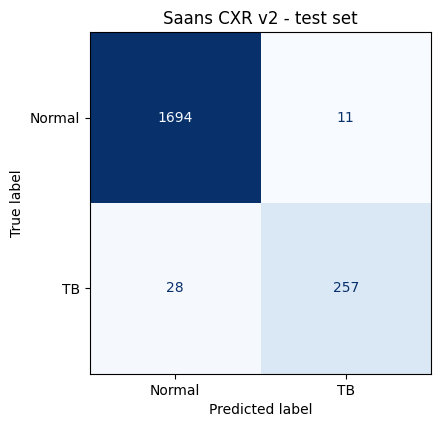

In [12]:
# BLOCK 4 (cont.) - FINAL numbers, on the untouched test set.
test_prob = model.predict(test_ds, verbose=0).ravel()
y_true = y_test.astype(int)
y_pred = (test_prob >= THRESHOLD).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, test_prob)
pr_auc = average_precision_score(y_true, test_prob)

print("=" * 62)
print(f"TEST SET - {len(y_true)} films, scored once, at threshold {THRESHOLD:.4f}")
print("=" * 62)
print(f"  roc auc  : {auc:.4f}")
print(f"  pr auc   : {pr_auc:.4f}")
print(f"  recall   : {rec:.4f}   <- the one that matters for a screening tool")
print(f"  precision: {prec:.4f}")
print(f"  accuracy : {acc:.4f}   (inflated by class imbalance - do not lead with this)")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print(pd.DataFrame(cm, index=[f"true {c}" for c in CLASS_NAMES], columns=[f"pred {c}" for c in CLASS_NAMES]))
print(f"\nMissed TB (false negatives): {fn}    False alarms (false positives): {fp}")
print(f"specificity: {tn / (tn + fp):.4f}   (WHO triage benchmark is >= 0.70)")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Saans CXR v2 - test set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [13]:
# BLOCK 4 (cont.) - per-source breakdown on the test set.
# The four datasets were collected on different equipment and have very different
# TB rates (Shenzhen ~51% TB, TBX11K ~9.5%). A model can score well by recognising
# WHICH DATASET a film came from and playing that base rate, instead of finding
# disease. Even AUC across sources means it learned radiology; strong on one and
# weak on another means it learned scanners, and the headline number is misleading.
rows = []
for src in sorted(df_test["source"].unique()):
    m = (df_test["source"] == src).to_numpy()
    if m.sum() < 20 or len(np.unique(y_true[m])) < 2:
        continue
    rows.append(
        {
            "source": src,
            "films": int(m.sum()),
            "TB": int(y_true[m].sum()),
            "recall": round(float(recall_score(y_true[m], y_pred[m], zero_division=0)), 3),
            "precision": round(float(precision_score(y_true[m], y_pred[m], zero_division=0)), 3),
            "roc_auc": round(float(roc_auc_score(y_true[m], test_prob[m])), 3),
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

    source  films  TB  recall  precision  roc_auc
montgomery     21   6   0.500      1.000    0.933
     qatar    624 102   0.980      1.000    1.000
  shenzhen     94  50   0.780      0.951    0.942
    tbx11k   1251 127   0.906      0.927    0.993


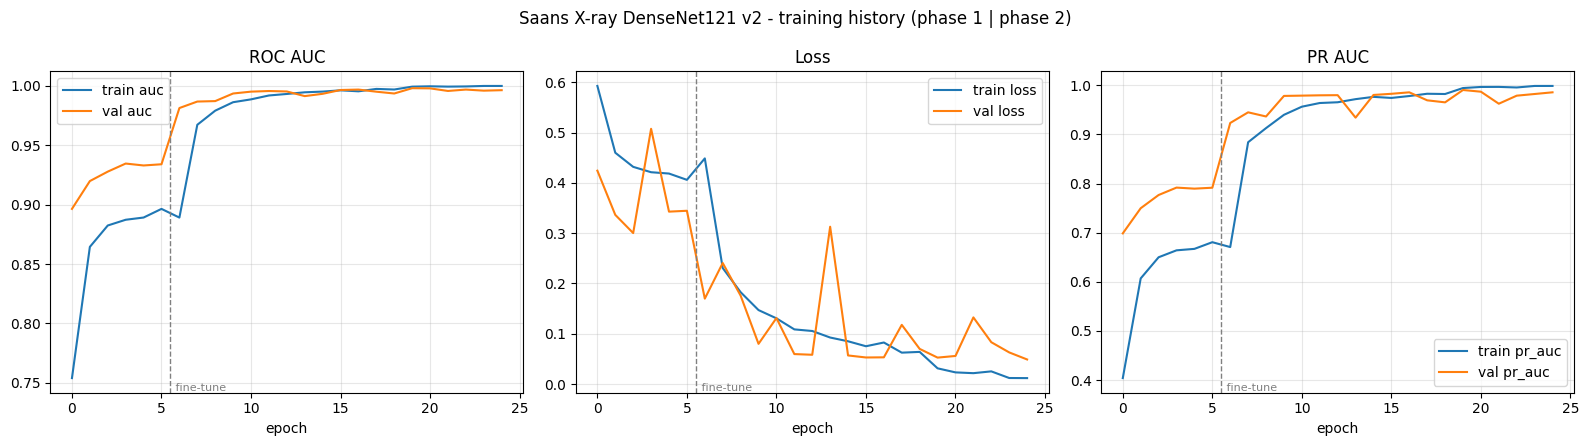

saved: training_curves.png, confusion_matrix.png


In [14]:
# BLOCK 4 (cont.) - training curves, saved to training_curves.png
n1 = len(hist1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, key, title in zip(axes, ["auc", "loss", "pr_auc"], ["ROC AUC", "Loss", "PR AUC"]):
    ax.plot(history[key], label=f"train {key}")
    ax.plot(history["val_" + key], label=f"val {key}")
    ax.axvline(n1 - 0.5, color="grey", ls="--", lw=1)
    ax.text(n1 - 0.4, ax.get_ylim()[0], " fine-tune", fontsize=8, color="grey", va="bottom")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle("Saans X-ray DenseNet121 v2 - training history (phase 1 | phase 2)")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("saved: training_curves.png, confusion_matrix.png")

## BLOCK 5 - Save

Saves `saans_xray_densenet121.h5`, reloads it from disk and re-scores the test
set to prove the file is intact, and writes a metadata sidecar carrying the
chosen threshold and the test metrics.


In [15]:
# BLOCK 5 - SAVE
WEIGHTS_PATH = "saans_xray_densenet121.h5"

model.save(WEIGHTS_PATH)
model.save_weights("saans_xray_densenet121.weights.h5")
print(f"saved {WEIGHTS_PATH}  ({os.path.getsize(WEIGHTS_PATH) / 1e6:.1f} MB)")

reloaded = tf.keras.models.load_model(WEIGHTS_PATH)
drift = float(np.max(np.abs(reloaded.predict(test_ds, verbose=0).ravel() - test_prob)))
print(f"reload check - max probability drift: {drift:.2e}")
assert drift < 1e-3, "the reloaded model does not match the trained one"
print("reload OK.")

metadata = {
    "model": "densenet121",
    "version": 2,
    "framework": f"tensorflow-{tf.__version__}",
    "input_shape": [IMG_SIZE, IMG_SIZE, 3],
    "preprocessing": "tf.keras.applications.densenet.preprocess_input (torch mode)",
    "output": "single sigmoid unit, P(TB)",
    "classes": {"0": "Normal", "1": "TB"},
    "threshold": round(float(THRESHOLD), 4),
    "threshold_chosen_for": f"recall >= {TARGET_RECALL} on the validation split",
    "gradcam_layer": "conv5_block16_concat",
    "train_datasets": sorted(df["source"].unique().tolist()),
    "n_train": int(len(y_train)),
    "n_val": int(len(y_val)),
    "n_test": int(len(y_test)),
    "test_metrics": {
        "roc_auc": round(float(auc), 4),
        "pr_auc": round(float(pr_auc), 4),
        "recall": round(float(rec), 4),
        "precision": round(float(prec), 4),
        "accuracy": round(float(acc), 4),
        "specificity": round(float(tn / (tn + fp)), 4),
        "confusion_matrix": cm.tolist(),
    },
    "scope_note": (
        "Trained on adult TB CXR datasets as proof-of-concept; paediatric fine-tuning "
        "is the Phase-1 pilot roadmap item. Chest X-ray is a triage aid, not a diagnosis - "
        "bacteriological confirmation remains the diagnostic standard."
    ),
}
with open("saans_xray_densenet121.json", "w") as fh:
    json.dump(metadata, fh, indent=2)
print(json.dumps(metadata, indent=2))

saved saans_xray_densenet121.h5  (73.3 MB)
reload check - max probability drift: 0.00e+00
reload OK.
{
  "model": "densenet121",
  "version": 2,
  "framework": "tensorflow-2.10.1",
  "input_shape": [
    224,
    224,
    3
  ],
  "preprocessing": "tf.keras.applications.densenet.preprocess_input (torch mode)",
  "output": "single sigmoid unit, P(TB)",
  "classes": {
    "0": "Normal",
    "1": "TB"
  },
  "threshold": 0.9807,
  "threshold_chosen_for": "recall >= 0.9 on the validation split",
  "gradcam_layer": "conv5_block16_concat",
  "train_datasets": [
    "montgomery",
    "qatar",
    "shenzhen",
    "tbx11k"
  ],
  "n_train": 9285,
  "n_val": 1990,
  "n_test": 1990,
  "test_metrics": {
    "roc_auc": 0.9949,
    "pr_auc": 0.9839,
    "recall": 0.9018,
    "precision": 0.959,
    "accuracy": 0.9804,
    "specificity": 0.9935,
    "confusion_matrix": [
      [
        1694,
        11
      ],
      [
        28,
        257
      ]
    ]
  },
  "scope_note": "Trained on adult TB C

## BLOCK 6 - Grad-CAM

Unchanged from v1: gradients of the TB **logit** with respect to
`conv5_block16_concat`, pooled into weights, ReLU, normalised, upsampled, blended.
The sigmoid is swapped for a linear activation while taping so gradients survive
a confident prediction, and the feature maps are cast to float32 because mixed
precision leaves them in float16.


In [17]:
# BLOCK 6 - GRAD-CAM
LAST_CONV_LAYER = "conv5_block16_concat"
_GRAD_MODELS = {}


def _grad_model_for(model, last_conv_layer_name):
    key = (id(model), last_conv_layer_name)
    if key not in _GRAD_MODELS:
        _GRAD_MODELS[key] = tf.keras.models.Model(
            model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
        )
    return _GRAD_MODELS[key]


def make_gradcam_heatmap(preprocessed_batch, model=None, last_conv_layer_name=LAST_CONV_LAYER):
    """Real Grad-CAM. Input (1,224,224,3) already preprocessed. Returns a 7x7 map in [0,1]."""
    model = model if model is not None else globals()["model"]
    head = model.get_layer("tb_output")
    saved_activation = head.activation
    head.activation = tf.keras.activations.linear      # tape the logit, not the squashed probability
    try:
        grad_model = _grad_model_for(model, last_conv_layer_name)
        with tf.GradientTape() as tape:
            conv_out, logit = grad_model(preprocessed_batch, training=False)
            score = logit[:, 0]
        grads = tape.gradient(score, conv_out)
        if grads is None:
            raise RuntimeError("no gradient reached the target conv layer")
        conv_out = tf.cast(conv_out, tf.float32)        # mixed precision leaves these in float16
        grads = tf.cast(grads, tf.float32)
        weights = tf.reduce_mean(grads, axis=(1, 2))
        cam = tf.nn.relu(tf.einsum("bhwc,bc->bhw", conv_out, weights)[0])
        cam = cam / (tf.reduce_max(cam) + 1e-8)
    finally:
        head.activation = saved_activation
    return cam.numpy()


def overlay_heatmap(pil_image, cam, alpha=0.45, size=(512, 512)):
    """Blend a [0,1] Grad-CAM map over the film with a jet colour ramp."""
    base_arr = np.asarray(pil_image.convert("RGB").resize(size, Image.BICUBIC)).astype("float32") / 255.0
    cam_up = np.asarray(
        Image.fromarray(np.uint8(np.clip(cam, 0, 1) * 255)).resize(size, Image.BICUBIC)
    ).astype("float32") / 255.0
    heat = plt.get_cmap("jet")(cam_up)[..., :3]
    mask = (cam_up ** 1.5)[..., None] * alpha
    return Image.fromarray(np.uint8(np.clip(base_arr * (1.0 - mask) + heat * mask, 0, 1) * 255))


def load_for_model(image):
    """Path / PIL image -> (preprocessed (1,224,224,3) batch, original PIL image)."""
    if isinstance(image, (str, os.PathLike, Path)):
        image = Image.open(image)
    image.load()
    arr = np.asarray(image.convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR), dtype="float32")[None, ...]
    return preprocess_input(arr.copy()), image


print("Grad-CAM target layer:", model.get_layer(LAST_CONV_LAYER).output.shape)

Grad-CAM target layer: (None, 7, 7, 1024)


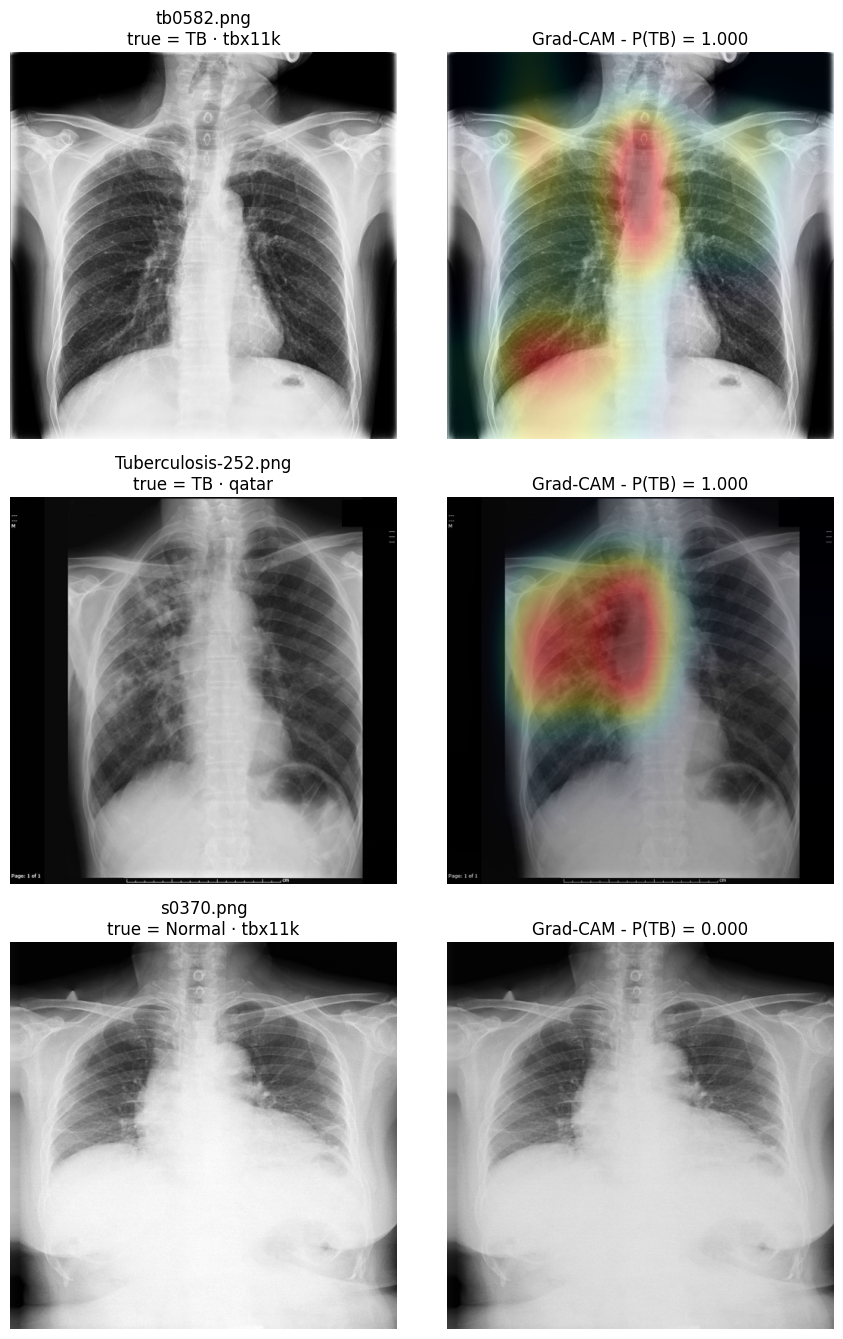

Check the heat sits on lung tissue. If it lands on a corner, a text marker or
the image border, the model has learned something about how the films were
taken rather than about disease - and the score is not trustworthy.


In [18]:
# BLOCK 6 (cont.) - Grad-CAM on real test films the model got right.
picks = list(df_test.index[(y_true == 1) & (y_pred == 1)][:2]) + list(
    df_test.index[(y_true == 0) & (y_pred == 0)][:1]
)
if not picks:
    picks = list(df_test.index[:3])

fig, axes = plt.subplots(len(picks), 2, figsize=(9, 4.5 * len(picks)))
axes = np.atleast_2d(axes)
for row, i in enumerate(picks):
    path = df_test.loc[i, "path"]
    batch_in, original = load_for_model(path)
    cam = make_gradcam_heatmap(batch_in)
    axes[row, 0].imshow(original.convert("L"), cmap="gray")
    axes[row, 0].set_title(f"{Path(path).name}\ntrue = {CLASS_NAMES[y_true[i]]} · {df_test.loc[i, 'source']}")
    axes[row, 1].imshow(overlay_heatmap(original, cam))
    axes[row, 1].set_title(f"Grad-CAM - P(TB) = {test_prob[i]:.3f}")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()
print("Check the heat sits on lung tissue. If it lands on a corner, a text marker or")
print("the image border, the model has learned something about how the films were")
print("taken rather than about disease - and the score is not trustworthy.")

## BLOCK 7 - Inference

`predict_xray(image)` -> `{"tb_probability": float, "heatmap_image": PIL.Image}`,
plus `heatmap_to_data_url()` for the FastAPI layer. The final cell pushes the
whole test split back through the public function to confirm it reproduces the
Block 4 numbers - the check that catches training/serving preprocessing drift.


input : tb0582.png (true: TB)
output: {'tb_probability': 1.0, 'heatmap_image': <PIL.Image.Image image mode=RGB size=512x512 at 0x244A3C85060>}
verdict: TB-suspect


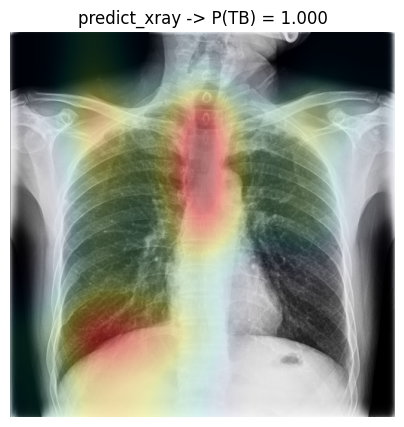

In [19]:
# BLOCK 7 - INFERENCE
# Trained on adult TB CXR datasets as proof-of-concept; paediatric fine-tuning is
# the Phase-1 pilot roadmap item. Every output is decision support for a health
# worker, never a diagnosis.
import base64
import io


def predict_xray(image, model=None, threshold=None, alpha=0.45):
    """
    New chest X-ray in -> TB probability + Grad-CAM overlay out.

    image: file path, PIL.Image, or raw image bytes.
    returns: {"tb_probability": float, "heatmap_image": PIL.Image}
    """
    model = model if model is not None else globals()["model"]
    if isinstance(image, (bytes, bytearray)):
        image = Image.open(io.BytesIO(image))
    batch_in, original = load_for_model(image)
    probability = float(model.predict(batch_in, verbose=0)[0][0])
    cam = make_gradcam_heatmap(batch_in, model)
    return {
        "tb_probability": round(probability, 4),
        "heatmap_image": overlay_heatmap(original, cam, alpha=alpha),
    }


def heatmap_to_data_url(pil_image):
    """PNG data URL, ready for the Saans API response / an <img src>."""
    buf = io.BytesIO()
    pil_image.save(buf, format="PNG", optimize=True)
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")


sample_path = df_test.loc[picks[0], "path"]
result = predict_xray(sample_path)
print("input :", Path(sample_path).name, f"(true: {CLASS_NAMES[int(df_test.loc[picks[0], 'label'])]})")
print("output:", {"tb_probability": result["tb_probability"], "heatmap_image": result["heatmap_image"]})
print("verdict:", "TB-suspect" if result["tb_probability"] >= THRESHOLD else "no TB features detected")

plt.figure(figsize=(5, 5))
plt.imshow(result["heatmap_image"])
plt.axis("off")
plt.title(f"predict_xray -> P(TB) = {result['tb_probability']:.3f}")
plt.show()

In [20]:
# BLOCK 7 (cont.) - sweep a sample of the test split through the public function,
# so what ships is what was measured.
sample = df_test.sample(n=min(300, len(df_test)), random_state=SEED)
sweep = np.array([predict_xray(p)["tb_probability"] for p in tqdm(sample["path"], desc="predict_xray")])
sweep_true = sample["label"].to_numpy().astype(int)
print(f"recall through predict_xray(): {recall_score(sweep_true, (sweep >= THRESHOLD).astype(int)):.4f}")
print(f"reported test recall:          {rec:.4f}")
print("(a sample, so small differences are expected - a large gap means the")
print(" serving path preprocesses differently from training)")

predict_xray: 100%|██████████| 300/300 [02:20<00:00,  2.13it/s]

recall through predict_xray(): 0.9111
reported test recall:          0.9018
(a sample, so small differences are expected - a large gap means the
 serving path preprocesses differently from training)


## BLOCK 8 - Put the weights into the repo

Everything is already on your disk - there is no download step. This cell copies
the trained model and its metadata into `backend/models/` for you.

**Backend note:** `server/vision.py` currently loads PyTorch weights. This is a
Keras `.h5`, so `load_model()` / `run_model()` there need swapping to
`tf.keras.models.load_model(...)` plus the Grad-CAM from Block 6 - and the
threshold in the metadata json should drive the decision, not a hardcoded 0.5.


In [21]:
# BLOCK 8 - copy the weights into the repo
import shutil

REPO_MODELS = Path(r"D:\Ai agents Projects\Saans\backend\models")
REPO_MODELS.mkdir(parents=True, exist_ok=True)

for name in [
    "saans_xray_densenet121.h5",
    "saans_xray_densenet121.json",
    "training_curves.png",
    "confusion_matrix.png",
]:
    if os.path.exists(name):
        shutil.copy(name, REPO_MODELS / name)
        print(f"copied {name} -> {REPO_MODELS / name}  ({os.path.getsize(name) / 1e6:.1f} MB)")
    else:
        print(f"missing: {name} - run the earlier blocks first")

print()
print("Weights are gitignored, so they stay out of version control.")

copied saans_xray_densenet121.h5 -> D:\Ai agents Projects\Saans\backend\models\saans_xray_densenet121.h5  (73.3 MB)
copied saans_xray_densenet121.json -> D:\Ai agents Projects\Saans\backend\models\saans_xray_densenet121.json  (0.0 MB)
copied training_curves.png -> D:\Ai agents Projects\Saans\backend\models\training_curves.png  (0.1 MB)
copied confusion_matrix.png -> D:\Ai agents Projects\Saans\backend\models\confusion_matrix.png  (0.0 MB)

Weights are gitignored, so they stay out of version control.


In [1]:
rows = []
for src in sorted(df_test["source"].unique()):
    m = (df_test["source"] == src).to_numpy()
    if m.sum() < 20 or len(np.unique(y_true[m])) < 2:
        continue
    rows.append({
        "source": src,
        "films": int(m.sum()),
        "TB": int(y_true[m].sum()),
        "recall": round(float(recall_score(y_true[m], y_pred[m], zero_division=0)), 3),
        "precision": round(float(precision_score(y_true[m], y_pred[m], zero_division=0)), 3),
        "roc_auc": round(float(roc_auc_score(y_true[m], test_prob[m])), 3),
    })
print(pd.DataFrame(rows).to_string(index=False))

NameError: name 'df_test' is not defined